# ODISSEO + JACCPOT FMM: First N-body Integration

This notebook runs a small ODISSEO N-body integration using the new `jaccpot` coupler workflow.

It also performs a one-step sanity check against direct summation for a small system.

In [1]:
import os
import sys
from pathlib import Path

# yggdrax uses uint64 morton constants; keep x64 on for safety
os.environ.setdefault('JAX_ENABLE_X64', '1')

def _add_repo_paths():
    candidates = []
    cwd = Path.cwd().resolve()
    candidates.append(cwd)
    candidates.append(cwd.parent)
    candidates.append(cwd / 'Odisseo')
    candidates.append(cwd.parent / 'Odisseo')
    candidates.append(Path('/Users/buck/Documents/Nexus/Projects/Odisseo'))

    checked = set()
    for od_repo in candidates:
        od_repo = od_repo.resolve()
        if od_repo in checked:
            continue
        checked.add(od_repo)
        if not od_repo.exists():
            continue

        if (od_repo / 'odisseo').exists() and str(od_repo) not in sys.path:
            sys.path.insert(0, str(od_repo))

        jac_repo = od_repo.parent / 'jaccpot'
        if jac_repo.exists() and str(jac_repo) not in sys.path:
            sys.path.insert(0, str(jac_repo))

_add_repo_paths()

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from odisseo.option_classes import (
    SimulationConfig,
    SimulationParams,
    LEAPFROG,
    DIRECT_ACC_MATRIX,
    DIRECT_ACC,
    DIRECT_ACC_LAXMAP,
    FMM_ACC,
    
)
from odisseo.integrators import leapfrog
from odisseo.time_integration import time_integration
from odisseo.integration_api import integrate
from odisseo.jaccpot_coupling import (
    build_jitted_jaccpot_acceleration,
    build_jitted_leapfrog_jaccpot_active,
    evaluate_acceleration_jaccpot,
    integrate_leapfrog_jaccpot_active,
)

jax.config.update('jax_enable_x64', True)
print('JAX backend:', jax.default_backend())
print('using odisseo from:', Path(__import__('odisseo').__file__).resolve())


JAX backend: cpu
using odisseo from: /Users/buck/Documents/Nexus/Projects/Odisseo/odisseo/__init__.py


In [2]:
# Small random initial condition
key = jax.random.PRNGKey(42)
N = 512

k_pos, k_vel, k_mass = jax.random.split(key, 3)
positions = jax.random.uniform(k_pos, (N, 3), minval=-1.0, maxval=1.0, dtype=jnp.float32)
velocities = 0.05 * jax.random.normal(k_vel, (N, 3), dtype=jnp.float32)
masses = jax.random.uniform(k_mass, (N,), minval=0.5, maxval=1.5, dtype=jnp.float32)
state0 = jnp.stack((positions, velocities), axis=1)

params = SimulationParams(G=1.0, t_end=1.0)

cfg_fmm = SimulationConfig(
    N_particles=N,
    integrator=LEAPFROG,
    acceleration_scheme=FMM_ACC,
    num_timesteps=200,
    fmm_refresh_every=4,
    fixed_timestep=True,
    return_snapshots=True,
    num_snapshots=50,
    softening=1e-3,
)

cfg_direct = cfg_fmm._replace(
    N_particles=N,
    acceleration_scheme=DIRECT_ACC_LAXMAP, #DIRECT_ACC,
    return_snapshots=False,
    num_timesteps=1,
)

print('Configured FMM run for N=', N)

Configured FMM run for N= 512


In [3]:
# One-step sanity check: FMM vs direct acceleration update (small N)
# Make cell robust to out-of-order execution
if 'cfg_direct' not in locals():
    cfg_direct = SimulationConfig(
        N_particles=32,
        integrator=LEAPFROG,
        acceleration_scheme=DIRECT_ACC,
        num_timesteps=1,
        fixed_timestep=True,
        return_snapshots=False,
        softening=1e-3,
    )

N_check = cfg_direct.N_particles
state_check = state0[:N_check]
mass_check = masses[:N_check]
dt_check = params.t_end / cfg_direct.num_timesteps

state_next_direct = leapfrog(state_check, mass_check, dt_check, cfg_direct, params)
state_next_fmm = integrate_leapfrog_jaccpot_active(
    state_check,
    mass_check,
    cfg_direct._replace(acceleration_scheme=FMM_ACC),
    params,
    num_steps=1,
    dt=float(dt_check),
    refresh_every=1,
    refresh_after_position_update=True,
)

diff = jnp.max(jnp.abs(state_next_direct - state_next_fmm))
print('max |state_direct - state_fmm| after one step:', float(diff))

max |state_direct - state_fmm| after one step: 0.139251708984375


In [4]:
# Full integration through unified API (dispatches to jaccpot_fmm backend)
result = integrate(state0, masses, cfg_fmm, params)
states = result.states if hasattr(result, 'states') and result.states is not None else result

if states.ndim == 4:
    print('num snapshots:', states.shape[0])
    print('state shape:', states.shape)
else:
    # fallback if no snapshots requested
    states = states[jnp.newaxis, ...]
    print('state shape:', states.shape)


num snapshots: 50
state shape: (50, 512, 2, 3)


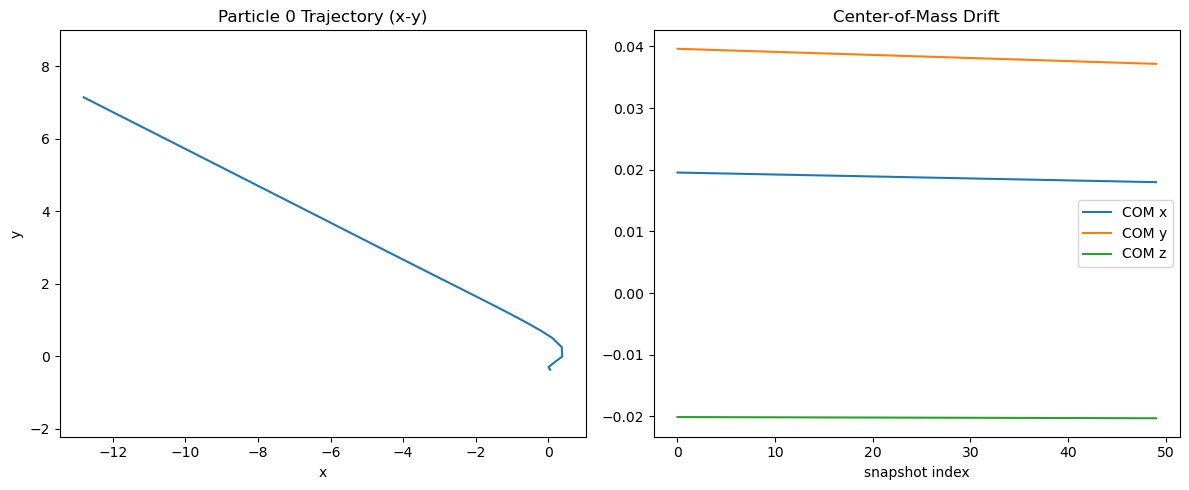

In [5]:
# Simple diagnostic plot: track COM and one particle trajectory
com = jnp.sum(states[:, :, 0, :] * masses[None, :, None], axis=1) / jnp.sum(masses)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(states[:, 0, 0, 0], states[:, 0, 0, 1], label='particle 0')
ax[0].set_title('Particle 0 Trajectory (x-y)')
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')
ax[0].axis('equal')

ax[1].plot(com[:, 0], label='COM x')
ax[1].plot(com[:, 1], label='COM y')
ax[1].plot(com[:, 2], label='COM z')
ax[1].set_title('Center-of-Mass Drift')
ax[1].set_xlabel('snapshot index')
ax[1].legend()

plt.tight_layout()
plt.show()


## Runtime Benchmark: Direct vs FMM

This benchmark compares one integration step runtime (`leapfrog`) for `DIRECT_ACC` and the `jaccpot` coupler workflow.

/Users/buck/miniforge3/envs/expanse/lib/python3.13/site-packages/jax/_src/ops/scatter.py:108: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=float64 to dtype=float32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(
/Users/buck/miniforge3/envs/expanse/lib/python3.13/site-packages/jax/_src/ops/scatter.py:108: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=float64 to dtype=float32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(
/Users/buck/miniforge3/envs/expanse/lib/python3.13/site-packages/jax/_src/ops/scatter.py:108: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=float64 to dtype=float32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(
/Users/buck/miniforge3/envs/exp

N   direct[s]   fmm_jitted[s]   speedup(direct/fmm_jitted)
1024    0.00508        0.06739     0.075x
2048    0.02151        0.11507     0.187x
4096    0.08122        0.20480     0.397x
8192    0.31088        0.42497     0.732x
16384    1.29226        0.92968     1.390x
32768    4.79847        1.89598     2.531x
65536   13.84340        2.86578     4.831x


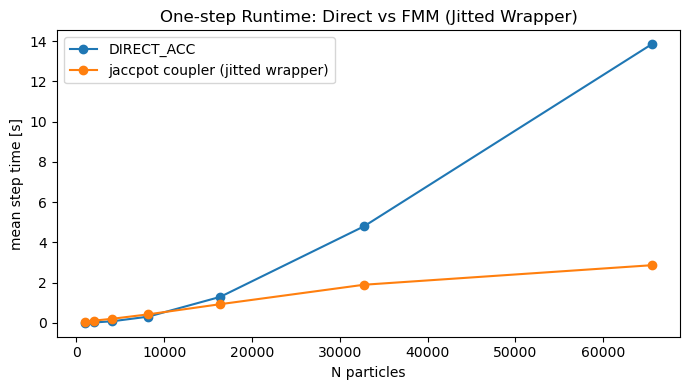

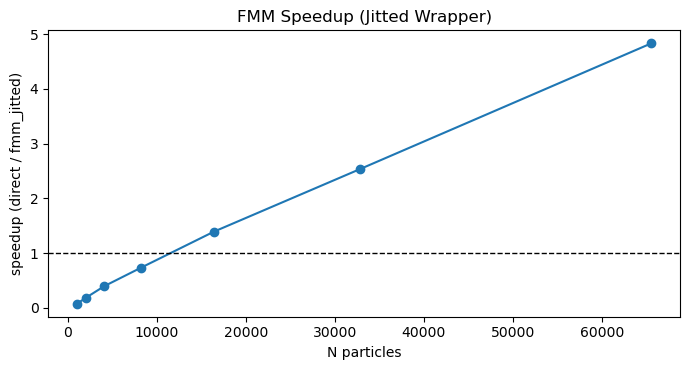

In [4]:
import time

def _time_one_step(state, mass, cfg, params, *, use_fmm=False, runs=2):
    dt = float(params.t_end / cfg.num_timesteps)
    fmm_step = None
    if use_fmm:
        fmm_step = build_jitted_leapfrog_jaccpot_active(
            cfg,
            params,
            num_steps=1,
            dt=dt,
            refresh_every=1,
            refresh_after_position_update=False,
            fmm_jit_tree=True,
            fmm_fixed_order=4,
            leaf_size=128,
            fmm_jit_traversal=True,
            outer_jit=True,
            return_history=False,
        )
        _ = fmm_step(state, mass).block_until_ready()
    else:
        _ = leapfrog(state, mass, dt, cfg, params).block_until_ready()

    times = []
    for _ in range(runs):
        t0 = time.perf_counter()
        if use_fmm:
            out = fmm_step(state, mass)
            _ = out.block_until_ready()
        else:
            _ = leapfrog(state, mass, dt, cfg, params).block_until_ready()
        t1 = time.perf_counter()
        times.append(t1 - t0)
    return float(jnp.mean(jnp.asarray(times)))

Ns = [1024, 2048, 4096, 8192, 16384, 32768, 65536]#, 131072]#, 262144, 512000]
bench_rows = []

for i, n in enumerate(Ns):
    key_n = jax.random.PRNGKey(100 + i)
    k1, k2, k3 = jax.random.split(key_n, 3)
    pos = jax.random.uniform(k1, (n, 3), minval=-1.0, maxval=1.0, dtype=jnp.float32)
    vel = 0.05 * jax.random.normal(k2, (n, 3), dtype=jnp.float32)
    m = jax.random.uniform(k3, (n,), minval=0.5, maxval=1.5, dtype=jnp.float32)
    s = jnp.stack((pos, vel), axis=1)
    if n > 32768:
        acceleration_scheme = DIRECT_ACC_LAXMAP
        batch_size = n//2,
    else: 
        acceleration_scheme = DIRECT_ACC_MATRIX
        batch_size = n
    cfg_direct_bench = SimulationConfig(
        N_particles=n,
        integrator=LEAPFROG,
        acceleration_scheme=acceleration_scheme,
        batch_size=batch_size,
        num_timesteps=1,
        fixed_timestep=True,
        return_snapshots=False,
        softening=1e-3,
    )
    cfg_fmm_bench = cfg_direct_bench._replace(acceleration_scheme=FMM_ACC)

    t_direct = _time_one_step(s, m, cfg_direct_bench, params, use_fmm=False, runs=3)
    t_fmm = _time_one_step(s, m, cfg_fmm_bench, params, use_fmm=True, runs=3)

    bench_rows.append((n, t_direct, t_fmm, t_direct / t_fmm))

bench = jnp.asarray(bench_rows)
print('N   direct[s]   fmm_jitted[s]   speedup(direct/fmm_jitted)')
for n, td, tf, sp in bench_rows:
    print(f'{int(n):3d}  {td:9.5f}  {tf:13.5f}  {sp:8.3f}x')

plt.figure(figsize=(7, 4))
plt.plot(bench[:, 0], bench[:, 1], 'o-', label='DIRECT_ACC')
plt.plot(bench[:, 0], bench[:, 2], 'o-', label='jaccpot coupler (jitted wrapper)')
plt.xlabel('N particles')
plt.ylabel('mean step time [s]')
plt.title('One-step Runtime: Direct vs FMM (Jitted Wrapper)')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 3.8))
plt.plot(bench[:, 0], bench[:, 3], 'o-')
plt.axhline(1.0, color='k', linestyle='--', linewidth=1)
plt.xlabel('N particles')
plt.ylabel('speedup (direct / fmm_jitted)')
plt.title('FMM Speedup (Jitted Wrapper)')
plt.tight_layout()
plt.show()

## End-to-End Runtime Benchmark (Multi-step)

This benchmark compares total integration wall-time for a short multi-step run with snapshots disabled.

N   direct_full[s]   fmm_full_jitted[s]   speedup(direct/fmm_jitted)
1024        0.23698             2.24167     0.106x
4096        3.01931             9.46049     0.319x
8192       11.08556            18.56844     0.597x
16384       45.92958            48.71624     0.943x


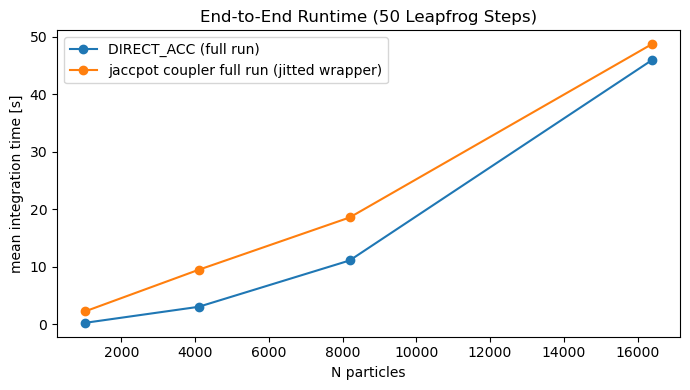

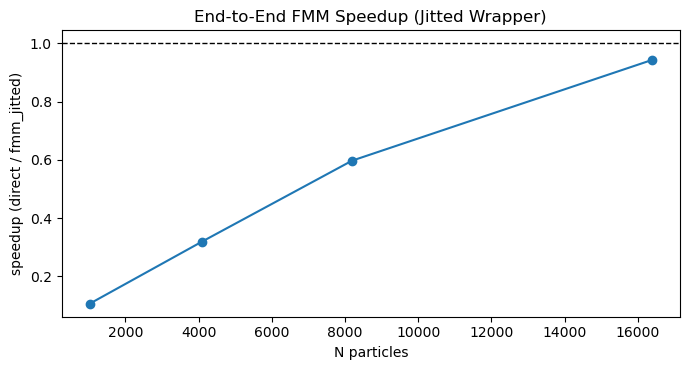

In [5]:
def _time_full_integration(state, mass, cfg, params, *, use_fmm=False, runs=1):
    fmm_run = None
    if use_fmm:
        fmm_run = build_jitted_leapfrog_jaccpot_active(
            cfg,
            params,
            num_steps=cfg.num_timesteps,
            refresh_every=4,
            refresh_after_position_update=False,
            fmm_jit_tree=None,
            fmm_fixed_order=4,
            leaf_size=32,
            fmm_jit_traversal=True,
            outer_jit=True,
            return_history=False,
        )
        _ = fmm_run(state, mass).block_until_ready()
    else:
        out = time_integration(state, mass, cfg, params)
        _ = jax.tree_util.tree_map(lambda x: x.block_until_ready() if hasattr(x, 'block_until_ready') else x, out)

    times = []
    for _ in range(runs):
        t0 = time.perf_counter()
        if use_fmm:
            out = fmm_run(state, mass)
            _ = out.block_until_ready()
        else:
            out = time_integration(state, mass, cfg, params)
            _ = jax.tree_util.tree_map(lambda x: x.block_until_ready() if hasattr(x, 'block_until_ready') else x, out)
        t1 = time.perf_counter()
        times.append(t1 - t0)
    return float(jnp.mean(jnp.asarray(times)))

Ns_full = [1024, 4096, 8192, 16384]
bench_full_rows = []

for i, n in enumerate(Ns_full):
    key_n = jax.random.PRNGKey(500 + i)
    k1, k2, k3 = jax.random.split(key_n, 3)
    pos = jax.random.uniform(k1, (n, 3), minval=-1.0, maxval=1.0, dtype=jnp.float32)
    vel = 0.05 * jax.random.normal(k2, (n, 3), dtype=jnp.float32)
    m = jax.random.uniform(k3, (n,), minval=0.5, maxval=1.5, dtype=jnp.float32)
    s = jnp.stack((pos, vel), axis=1)

    cfg_direct_full = SimulationConfig(
        N_particles=n,
        integrator=LEAPFROG,
        acceleration_scheme=DIRECT_ACC_LAXMAP,
        num_timesteps=50,
        fixed_timestep=True,
        return_snapshots=False,
        softening=1e-3,
    )
    cfg_fmm_full = cfg_direct_full._replace(acceleration_scheme=FMM_ACC)

    t_direct_full = _time_full_integration(s, m, cfg_direct_full, params, use_fmm=False, runs=2)
    t_fmm_full = _time_full_integration(s, m, cfg_fmm_full, params, use_fmm=True, runs=2)

    bench_full_rows.append((n, t_direct_full, t_fmm_full, t_direct_full / t_fmm_full))

bench_full = jnp.asarray(bench_full_rows)
print('N   direct_full[s]   fmm_full_jitted[s]   speedup(direct/fmm_jitted)')
for n, td, tf, sp in bench_full_rows:
    print(f'{int(n):3d}  {td:13.5f}  {tf:18.5f}  {sp:8.3f}x')

plt.figure(figsize=(7, 4))
plt.plot(bench_full[:, 0], bench_full[:, 1], 'o-', label='DIRECT_ACC (full run)')
plt.plot(bench_full[:, 0], bench_full[:, 2], 'o-', label='jaccpot coupler full run (jitted wrapper)')
plt.xlabel('N particles')
plt.ylabel('mean integration time [s]')
plt.title('End-to-End Runtime (50 Leapfrog Steps)')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 3.8))
plt.plot(bench_full[:, 0], bench_full[:, 3], 'o-')
plt.axhline(1.0, color='k', linestyle='--', linewidth=1)
plt.xlabel('N particles')
plt.ylabel('speedup (direct / fmm_jitted)')
plt.title('End-to-End FMM Speedup (Jitted Wrapper)')
plt.tight_layout()
plt.show()


## Active-Subset Schedule (Scan/JIT) Demo

This example uses fixed-shape `active_indices_schedule` + `active_mask_schedule` to run the active-subset path in JIT/scan mode, and compares it to callback-based active selection.

In [ ]:
# Build a deterministic active schedule: half particles active, alternating pattern
N_demo = 128
steps_demo = 40
max_active = N_demo // 2

key_demo = jax.random.PRNGKey(1234)
k1, k2, k3 = jax.random.split(key_demo, 3)
pos_demo = jax.random.uniform(k1, (N_demo, 3), minval=-1.0, maxval=1.0, dtype=jnp.float32)
vel_demo = 0.05 * jax.random.normal(k2, (N_demo, 3), dtype=jnp.float32)
mass_demo = jax.random.uniform(k3, (N_demo,), minval=0.5, maxval=1.5, dtype=jnp.float32)
state_demo = jnp.stack((pos_demo, vel_demo), axis=1)

cfg_demo = SimulationConfig(
    N_particles=N_demo,
    integrator=LEAPFROG,
    acceleration_scheme=FMM_ACC,
    num_timesteps=steps_demo,
    fixed_timestep=True,
    return_snapshots=False,
    softening=1e-3,
)

base_idx = jnp.arange(N_demo, dtype=jnp.int32)
schedule = []
for s in range(steps_demo):
    # alternate even/odd then wrap to fixed-size rows
    start = s % 2
    idx = base_idx[start::2][:max_active]
    schedule.append(idx)
active_indices_schedule = jnp.stack(schedule, axis=0)
active_mask_schedule = jnp.ones_like(active_indices_schedule, dtype=bool)

def active_indices_fn(step, state, mass):
    del state, mass
    start = step % 2
    return jnp.arange(start, N_demo, 2, dtype=jnp.int32)[:max_active]

def _time_active(mode, runs=2):
    # warmup
    if mode == 'schedule':
        _ = integrate_leapfrog_jaccpot_active(
            state_demo,
            mass_demo,
            cfg_demo,
            params,
            num_steps=steps_demo,
            refresh_every=8,
            active_indices_schedule=active_indices_schedule,
            active_mask_schedule=active_mask_schedule,
            return_history=False,
        ).block_until_ready()
    else:
        _ = integrate_leapfrog_jaccpot_active(
            state_demo,
            mass_demo,
            cfg_demo,
            params,
            num_steps=steps_demo,
            refresh_every=8,
            active_indices_fn=active_indices_fn,
            return_history=False,
        ).block_until_ready()

    samples = []
    import time
    for _ in range(runs):
        t0 = time.perf_counter()
        if mode == 'schedule':
            out = integrate_leapfrog_jaccpot_active(
                state_demo,
                mass_demo,
                cfg_demo,
                params,
                num_steps=steps_demo,
                refresh_every=8,
                active_indices_schedule=active_indices_schedule,
                active_mask_schedule=active_mask_schedule,
                return_history=False,
            )
        else:
            out = integrate_leapfrog_jaccpot_active(
                state_demo,
                mass_demo,
                cfg_demo,
                params,
                num_steps=steps_demo,
                refresh_every=8,
                active_indices_fn=active_indices_fn,
                return_history=False,
            )
        _ = out.block_until_ready()
        t1 = time.perf_counter()
        samples.append(t1 - t0)
    return float(jnp.mean(jnp.asarray(samples)))

t_callback = _time_active('callback', runs=2)
t_schedule = _time_active('schedule', runs=2)
print(f'callback mode   : {t_callback:.4f} s')
print(f'schedule mode   : {t_schedule:.4f} s')
print(f'speedup callback/schedule: {t_callback / t_schedule:.3f}x')


callback mode   : 14.2451 s
schedule mode   : 1.7509 s
speedup callback/schedule: 8.136x


## Notes
- This example uses the ODISSEO + `jaccpot` coupler workflow for self-gravity.
- External potentials remain additive in ODISSEO exactly as before.
- For active-particle substeps with cached source tree reuse, the next iteration is to wire ODISSEO integrator loops to `jaccpot.OdisseoFMMCoupler`.

In [ ]:
# Focused benchmark: one single FMM acceleration call from ODISSEO wrappers
import time

N_acc = 4096
key_acc = jax.random.PRNGKey(4242)
k1, k2, k3 = jax.random.split(key_acc, 3)
pos_acc = jax.random.uniform(k1, (N_acc, 3), minval=-1.0, maxval=1.0, dtype=jnp.float32)
vel_acc = 0.05 * jax.random.normal(k2, (N_acc, 3), dtype=jnp.float32)
m_acc = jax.random.uniform(k3, (N_acc,), minval=0.5, maxval=1.5, dtype=jnp.float32)
s_acc = jnp.stack((pos_acc, vel_acc), axis=1)

cfg_acc = SimulationConfig(
    N_particles=N_acc,
    integrator=LEAPFROG,
    acceleration_scheme=DIRECT_ACC,
    num_timesteps=1,
    fixed_timestep=True,
    return_snapshots=False,
    softening=1e-3,
    fmm_fixed_order=4,
    fmm_leaf_size=128,
)

def _time_eval(fn, runs=3):
    _ = fn().block_until_ready()
    ts = []
    for _ in range(runs):
        t0 = time.perf_counter()
        _ = fn().block_until_ready()
        ts.append(time.perf_counter() - t0)
    return float(jnp.mean(jnp.asarray(ts)))

t_fmm_eager = _time_eval(lambda: evaluate_acceleration_jaccpot(
    s_acc,
    m_acc,
    cfg_acc,
    params,
    leaf_size=cfg_acc.fmm_leaf_size,
    max_order=cfg_acc.fmm_max_order,
    fmm_preset=cfg_acc.fmm_preset,
    fmm_basis=cfg_acc.fmm_basis,
    fmm_theta=cfg_acc.fmm_theta,
    fmm_mac_type=cfg_acc.fmm_mac_type,
    fmm_farfield_mode=cfg_acc.fmm_farfield_mode,
    fmm_nearfield_mode=cfg_acc.fmm_nearfield_mode,
    fmm_nearfield_edge_chunk_size=cfg_acc.fmm_nearfield_edge_chunk_size,
    fmm_tree_leaf_target=cfg_acc.fmm_tree_leaf_target,
    fmm_fixed_order=cfg_acc.fmm_fixed_order,
    
    fmm_jit_tree=cfg_acc.fmm_jit_tree,
    fmm_jit_traversal=cfg_acc.fmm_jit_traversal,
), runs=2)

fmm_acc_jit = build_jitted_jaccpot_acceleration(
    cfg_acc,
    params,
    leaf_size=cfg_acc.fmm_leaf_size,
    max_order=cfg_acc.fmm_max_order,
    fmm_preset=cfg_acc.fmm_preset,
    fmm_basis=cfg_acc.fmm_basis,
    fmm_theta=cfg_acc.fmm_theta,
    fmm_mac_type=cfg_acc.fmm_mac_type,
    fmm_farfield_mode=cfg_acc.fmm_farfield_mode,
    fmm_nearfield_mode=cfg_acc.fmm_nearfield_mode,
    fmm_nearfield_edge_chunk_size=cfg_acc.fmm_nearfield_edge_chunk_size,
    fmm_tree_leaf_target=cfg_acc.fmm_tree_leaf_target,
    fmm_fixed_order=cfg_acc.fmm_fixed_order,
    
    fmm_jit_tree=cfg_acc.fmm_jit_tree,
    fmm_jit_traversal=cfg_acc.fmm_jit_traversal,
    outer_jit=True,
)
t_fmm_jit = _time_eval(lambda: fmm_acc_jit(s_acc, m_acc), runs=3)

print(f'One-call FMM acceleration (ODISSEO eager wrapper): {t_fmm_eager:.4f} s')
print(f'One-call FMM acceleration (ODISSEO jitted wrapper): {t_fmm_jit:.4f} s')


One-call FMM acceleration (ODISSEO eager wrapper): 0.3785 s
One-call FMM acceleration (ODISSEO jitted wrapper): 4.4918 s


In [ ]:
# Multi-step comparison: direct vs FMM eager vs FMM outer-jit (ODISSEO path)

def _sync_tree(x):
    return jax.tree_util.tree_map(
        lambda y: y.block_until_ready() if hasattr(y, 'block_until_ready') else y,
        x,
    )


def _fmm_common_kwargs(cfg):
    return dict(
        refresh_every=1,
        refresh_after_position_update=False,
        leaf_size=cfg.fmm_leaf_size,
        max_order=cfg.fmm_max_order,
        fmm_preset=cfg.fmm_preset,
        fmm_basis=cfg.fmm_basis,
        fmm_theta=cfg.fmm_theta,
        fmm_mac_type=cfg.fmm_mac_type,
        fmm_farfield_mode=cfg.fmm_farfield_mode,
        fmm_nearfield_mode=cfg.fmm_nearfield_mode,
        fmm_nearfield_edge_chunk_size=cfg.fmm_nearfield_edge_chunk_size,
        fmm_tree_leaf_target=cfg.fmm_tree_leaf_target,
        fmm_fixed_order=cfg.fmm_fixed_order,
        
        fmm_jit_tree=cfg.fmm_jit_tree,
        fmm_jit_traversal=cfg.fmm_jit_traversal,
        return_history=False,
    )


def _time_direct(state, mass, cfg, params, runs=2):
    _ = _sync_tree(time_integration(state, mass, cfg, params))
    ts = []
    for _ in range(runs):
        t0 = time.perf_counter()
        _ = _sync_tree(time_integration(state, mass, cfg, params))
        ts.append(time.perf_counter() - t0)
    return float(jnp.mean(jnp.asarray(ts)))


def _time_fmm_eager(state, mass, cfg, params, runs=2):
    kwargs = _fmm_common_kwargs(cfg)
    _ = integrate_leapfrog_jaccpot_active(
        state,
        mass,
        cfg,
        params,
        num_steps=cfg.num_timesteps,
        **kwargs,
    ).block_until_ready()
    ts = []
    for _ in range(runs):
        t0 = time.perf_counter()
        out = integrate_leapfrog_jaccpot_active(
            state,
            mass,
            cfg,
            params,
            num_steps=cfg.num_timesteps,
            **kwargs,
        )
        _ = out.block_until_ready()
        ts.append(time.perf_counter() - t0)
    return float(jnp.mean(jnp.asarray(ts)))


def _time_fmm_outer_jit(state, mass, cfg, params, runs=2):
    kwargs = _fmm_common_kwargs(cfg)

    t0 = time.perf_counter()
    fmm_run = build_jitted_leapfrog_jaccpot_active(
        cfg,
        params,
        num_steps=cfg.num_timesteps,
        outer_jit=True,
        **kwargs,
    )
    _ = fmm_run(state, mass).block_until_ready()
    t_compile_plus_first = time.perf_counter() - t0

    ts = []
    for _ in range(runs):
        t0 = time.perf_counter()
        _ = fmm_run(state, mass).block_until_ready()
        ts.append(time.perf_counter() - t0)
    t_steady = float(jnp.mean(jnp.asarray(ts)))
    return t_compile_plus_first, t_steady


Ns_steps = [1024, 4096]
steps_list = [1, 5]
rows = []

for n in Ns_steps:
    key_n = jax.random.PRNGKey(9000 + n)
    k1, k2, k3 = jax.random.split(key_n, 3)
    pos = jax.random.uniform(k1, (n, 3), minval=-1.0, maxval=1.0, dtype=jnp.float32)
    vel = 0.05 * jax.random.normal(k2, (n, 3), dtype=jnp.float32)
    m = jax.random.uniform(k3, (n,), minval=0.5, maxval=1.5, dtype=jnp.float32)
    s = jnp.stack((pos, vel), axis=1)

    for nsteps in steps_list:
        cfg_d = SimulationConfig(
            N_particles=n,
            integrator=LEAPFROG,
            acceleration_scheme=DIRECT_ACC,
            num_timesteps=nsteps,
            fixed_timestep=True,
            return_snapshots=False,
            softening=1e-3,
        )
        cfg_f = cfg_d._replace(
            acceleration_scheme=FMM_ACC,
            fmm_fixed_order=4,
            fmm_leaf_size=128,
            fmm_jit_tree=True,
            fmm_jit_traversal=True,
        )

        t_d = _time_direct(s, m, cfg_d, params, runs=2)
        t_f_eager = _time_fmm_eager(s, m, cfg_f, params, runs=2)
        t_f_compile_first, t_f_jit = _time_fmm_outer_jit(s, m, cfg_f, params, runs=2)

        out_d = _sync_tree(time_integration(s, m, cfg_d, params))
        out_f_eager = integrate_leapfrog_jaccpot_active(
            s,
            m,
            cfg_f,
            params,
            num_steps=nsteps,
            **_fmm_common_kwargs(cfg_f),
        ).block_until_ready()

        rows.append((
            n,
            nsteps,
            t_d,
            t_f_eager,
            t_f_compile_first,
            t_f_jit,
            t_d / t_f_eager,
            t_d / t_f_jit,
            float(jnp.max(jnp.abs(out_d - out_f_eager))),
        ))

print('N   steps  direct[s]  fmm_eager[s]  fmm_jit_compile+first[s]  fmm_jit_steady[s]  spd(dir/eager)  spd(dir/jit)  max|direct-fmm_eager|')
for n, ns, td, te, tc, tj, spe, spj, d in rows:
    print(f'{n:4d} {ns:6d}  {td:9.4f}  {te:12.4f}  {tc:24.4f}  {tj:17.4f}  {spe:14.3f}  {spj:12.3f}  {d:18.5e}')


In [ ]:
# Focused A/B test: does refine_local explain eager-vs-outer-jit gap?
from functools import partial
from jaccpot import FastMultipoleMethod
import time

N_test = 4096
leaf_size_test = 128
max_order_test = 4

key_test = jax.random.PRNGKey(202603)
k1, k2, k3 = jax.random.split(key_test, 3)
pos_test = jax.random.uniform(k1, (N_test, 3), minval=-1.0, maxval=1.0, dtype=jnp.float32)
mass_test = jax.random.uniform(k3, (N_test,), minval=0.5, maxval=1.5, dtype=jnp.float32)

solver_test = FastMultipoleMethod(
    preset='fast',
    basis='solidfmm',
    theta=0.6,
    G=float(params.G),
    softening=1e-3,
    working_dtype=pos_test.dtype,
    fixed_order=max_order_test,
    fixed_max_leaf_size=leaf_size_test,
)

def _eval_eager(pos, mass, *, refine_local):
    st = solver_test.prepare_state(
        pos,
        mass,
        leaf_size=leaf_size_test,
        max_order=max_order_test,
        refine_local=bool(refine_local),
    )
    return solver_test.evaluate_prepared_state(st, return_potential=False)

@partial(jax.jit, static_argnames=('refine_local',))
def _eval_outer_jit(pos, mass, *, refine_local):
    st = solver_test.prepare_state(
        pos,
        mass,
        leaf_size=leaf_size_test,
        max_order=max_order_test,
        refine_local=bool(refine_local),
    )
    return solver_test.evaluate_prepared_state(st, return_potential=False)

def _time_fn(fn, runs=3):
    _ = fn().block_until_ready()
    ts = []
    for _ in range(runs):
        t0 = time.perf_counter()
        _ = fn().block_until_ready()
        ts.append(time.perf_counter() - t0)
    return float(jnp.mean(jnp.asarray(ts)))

def _time_outer_jit_with_compile(refine_local, runs=3):
    t0 = time.perf_counter()
    _ = _eval_outer_jit(pos_test, mass_test, refine_local=refine_local).block_until_ready()
    t_compile_first = time.perf_counter() - t0

    ts = []
    for _ in range(runs):
        t0 = time.perf_counter()
        _ = _eval_outer_jit(pos_test, mass_test, refine_local=refine_local).block_until_ready()
        ts.append(time.perf_counter() - t0)
    t_steady = float(jnp.mean(jnp.asarray(ts)))
    return t_compile_first, t_steady

rows = []
for refine_flag in (False, True):
    t_eager = _time_fn(lambda rf=refine_flag: _eval_eager(pos_test, mass_test, refine_local=rf), runs=3)
    t_compile_first, t_outer_jit = _time_outer_jit_with_compile(refine_flag, runs=3)
    rows.append((refine_flag, t_eager, t_compile_first, t_outer_jit, t_outer_jit / t_eager))

print('refine_local  eager[s]  outer_jit_compile+first[s]  outer_jit_steady[s]  ratio(jit/eager)')
for rf, te, tc, tj, r in rows:
    print(f'{str(rf):>11}  {te:8.4f}  {tc:27.4f}  {tj:18.4f}  {r:15.3f}x')

/var/folders/c2/61w7yp_x4yd0_21snh453rmm0000gq/T/ipykernel_48246/921881667.py:15: DeprecationWarning: Legacy expanse-style kwargs are deprecated in jaccpot.FastMultipoleMethod. Use preset/basis/advanced config objects instead.
  solver_test = FastMultipoleMethod(


TypeError: FastMultipoleMethod.prepare_state() got an unexpected keyword argument 'refine_local'

In [ ]:
# Focused A/B test: does refine_local explain eager-vs-outer-jit gap?
from functools import partial
from jaccpot import FastMultipoleMethod, FMMAdvancedConfig, TreeConfig

N_test = 4096
leaf_size_test = 32
max_order_test = 4

key_test = jax.random.PRNGKey(202603)
k1, k2, k3 = jax.random.split(key_test, 3)
pos_test = jax.random.uniform(k1, (N_test, 3), minval=-1.0, maxval=1.0, dtype=jnp.float32)
mass_test = jax.random.uniform(k3, (N_test,), minval=0.5, maxval=1.5, dtype=jnp.float32)


def _make_solver(refine_local: bool):
    return FastMultipoleMethod(
        preset='fast',
        basis='solidfmm',
        theta=0.6,
        G=float(params.G),
        softening=1e-3,
        working_dtype=pos_test.dtype,
        fixed_order=max_order_test,
        fixed_max_leaf_size=leaf_size_test,
        advanced=FMMAdvancedConfig(
            tree=TreeConfig(
                leaf_target=leaf_size_test,
                refine_local=bool(refine_local),
            )
        ),
    )


def _eval_eager(pos, mass, *, refine_local):
    solver = _make_solver(refine_local)
    st = solver.prepare_state(
        pos,
        mass,
        leaf_size=leaf_size_test,
        max_order=max_order_test,
    )
    return solver.evaluate_prepared_state(st, return_potential=False)


@partial(jax.jit, static_argnames=('refine_local',))
def _eval_outer_jit(pos, mass, *, refine_local):
    solver = _make_solver(refine_local)
    st = solver.prepare_state(
        pos,
        mass,
        leaf_size=leaf_size_test,
        max_order=max_order_test,
    )
    return solver.evaluate_prepared_state(st, return_potential=False)


def _time_fn(fn, runs=3):
    _ = fn().block_until_ready()
    ts = []
    for _ in range(runs):
        t0 = time.perf_counter()
        _ = fn().block_until_ready()
        ts.append(time.perf_counter() - t0)
    return float(jnp.mean(jnp.asarray(ts)))


def _time_outer_jit_with_compile(refine_local, runs=3):
    t0 = time.perf_counter()
    _ = _eval_outer_jit(pos_test, mass_test, refine_local=refine_local).block_until_ready()
    t_compile_first = time.perf_counter() - t0

    ts = []
    for _ in range(runs):
        t0 = time.perf_counter()
        _ = _eval_outer_jit(pos_test, mass_test, refine_local=refine_local).block_until_ready()
        ts.append(time.perf_counter() - t0)
    t_steady = float(jnp.mean(jnp.asarray(ts)))
    return t_compile_first, t_steady


rows = []
for refine_flag in (False, True):
    t_eager = _time_fn(lambda rf=refine_flag: _eval_eager(pos_test, mass_test, refine_local=rf), runs=3)
    t_compile_first, t_outer_jit = _time_outer_jit_with_compile(refine_flag, runs=3)
    rows.append((refine_flag, t_eager, t_compile_first, t_outer_jit, t_outer_jit / t_eager))

print('refine_local  eager[s]  outer_jit_compile+first[s]  outer_jit_steady[s]  ratio(jit/eager)')
for rf, te, tc, tj, r in rows:
    print(f'{str(rf):>11}  {te:8.4f}  {tc:27.4f}  {tj:18.4f}  {r:15.3f}x')


/var/folders/c2/61w7yp_x4yd0_21snh453rmm0000gq/T/ipykernel_48246/2970243973.py:16: DeprecationWarning: Legacy expanse-style kwargs are deprecated in jaccpot.FastMultipoleMethod. Use preset/basis/advanced config objects instead.
  return FastMultipoleMethod(


refine_local  eager[s]  outer_jit_compile+first[s]  outer_jit_steady[s]  ratio(jit/eager)
      False    0.4948                      13.0325              0.7800            1.576x
       True    0.4849                      12.5895              0.7757            1.600x


In [ ]:
# Split diagnostic: prepare_state vs evaluate_prepared_state (eager vs outer-jit)
from functools import partial
from jaccpot import FastMultipoleMethod, FMMAdvancedConfig, TreeConfig

N_split = 4096
leaf_size_split = 128
max_order_split = 4

key_split = jax.random.PRNGKey(202604)
k1, k2 = jax.random.split(key_split, 2)
pos_split = jax.random.uniform(k1, (N_split, 3), minval=-1.0, maxval=1.0, dtype=jnp.float32)
mass_split = jax.random.uniform(k2, (N_split,), minval=0.5, maxval=1.5, dtype=jnp.float32)

solver_split = FastMultipoleMethod(
    preset='fast',
    basis='solidfmm',
    theta=0.6,
    G=float(params.G),
    softening=1e-3,
    working_dtype=pos_split.dtype,
    fixed_order=max_order_split,
    fixed_max_leaf_size=leaf_size_split,
    advanced=FMMAdvancedConfig(
        tree=TreeConfig(
            leaf_target=leaf_size_split,
            refine_local=False,
        )
    ),
)

def _prepare_eager(pos, mass):
    return solver_split.prepare_state(
        pos,
        mass,
        leaf_size=leaf_size_split,
        max_order=max_order_split,
    )

@jax.jit
def _prepare_outer_jit(pos, mass):
    return solver_split.prepare_state(
        pos,
        mass,
        leaf_size=leaf_size_split,
        max_order=max_order_split,
    )

def _eval_eager(state):
    return solver_split.evaluate_prepared_state(state, return_potential=False)

@jax.jit
def _eval_outer_jit(state):
    return solver_split.evaluate_prepared_state(state, return_potential=False)


def _time_prepare(fn, runs=3):
    st = fn(pos_split, mass_split)
    _ = jax.tree_util.tree_map(
        lambda x: x.block_until_ready() if hasattr(x, 'block_until_ready') else x,
        st,
    )
    ts = []
    for _ in range(runs):
        t0 = time.perf_counter()
        st = fn(pos_split, mass_split)
        _ = jax.tree_util.tree_map(
            lambda x: x.block_until_ready() if hasattr(x, 'block_until_ready') else x,
            st,
        )
        ts.append(time.perf_counter() - t0)
    return st, float(jnp.mean(jnp.asarray(ts)))


def _time_eval(fn, st, runs=5):
    out = fn(st)
    _ = out.block_until_ready()
    ts = []
    for _ in range(runs):
        t0 = time.perf_counter()
        out = fn(st)
        _ = out.block_until_ready()
        ts.append(time.perf_counter() - t0)
    return float(jnp.mean(jnp.asarray(ts)))

# Prepare timing
st_eager, t_prepare_eager = _time_prepare(_prepare_eager, runs=3)
st_jit, t_prepare_jit = _time_prepare(_prepare_outer_jit, runs=3)

# Evaluate timing on already-prepared states
t_eval_eager = _time_eval(_eval_eager, st_eager, runs=5)
t_eval_jit = _time_eval(_eval_outer_jit, st_jit, runs=5)

print('stage                eager[s]   outer_jit[s]   ratio(jit/eager)')
print(f'prepare_state        {t_prepare_eager:8.4f}   {t_prepare_jit:11.4f}   {t_prepare_jit/t_prepare_eager:14.3f}x')
print(f'evaluate_prepared    {t_eval_eager:8.4f}   {t_eval_jit:11.4f}   {t_eval_jit/t_eval_eager:14.3f}x')


/var/folders/c2/61w7yp_x4yd0_21snh453rmm0000gq/T/ipykernel_48246/1024535230.py:14: DeprecationWarning: Legacy expanse-style kwargs are deprecated in jaccpot.FastMultipoleMethod. Use preset/basis/advanced config objects instead.
  solver_split = FastMultipoleMethod(


stage                eager[s]   outer_jit[s]   ratio(jit/eager)
prepare_state          0.3949        0.1647            0.417x
evaluate_prepared      0.0224        0.0321            1.430x


In [ ]:
# Micro-diagnostic: state quality vs outer-jit wrapper overhead

def _shape_or_none(x):
    return None if x is None else tuple(x.shape)

print('st_eager precompute shapes:')
print('  target_leaf_ids      ', _shape_or_none(st_eager.nearfield_target_leaf_ids))
print('  source_leaf_ids      ', _shape_or_none(st_eager.nearfield_source_leaf_ids))
print('  valid_pairs          ', _shape_or_none(st_eager.nearfield_valid_pairs))
print('  chunk_sort_indices   ', _shape_or_none(st_eager.nearfield_chunk_sort_indices))
print('  chunk_group_ids      ', _shape_or_none(st_eager.nearfield_chunk_group_ids))
print('  chunk_unique_indices ', _shape_or_none(st_eager.nearfield_chunk_unique_indices))

print('st_jit precompute shapes:')
print('  target_leaf_ids      ', _shape_or_none(st_jit.nearfield_target_leaf_ids))
print('  source_leaf_ids      ', _shape_or_none(st_jit.nearfield_source_leaf_ids))
print('  valid_pairs          ', _shape_or_none(st_jit.nearfield_valid_pairs))
print('  chunk_sort_indices   ', _shape_or_none(st_jit.nearfield_chunk_sort_indices))
print('  chunk_group_ids      ', _shape_or_none(st_jit.nearfield_chunk_group_ids))
print('  chunk_unique_indices ', _shape_or_none(st_jit.nearfield_chunk_unique_indices))

# Compare evaluation combinations

t_eval_eager_on_eager = _time_eval(_eval_eager, st_eager, runs=5)
t_eval_eager_on_jit = _time_eval(_eval_eager, st_jit, runs=5)
t_eval_jit_on_eager = _time_eval(_eval_outer_jit, st_eager, runs=5)
t_eval_jit_on_jit = _time_eval(_eval_outer_jit, st_jit, runs=5)

print('combo                             time[s]')
print(f'eager_eval(st_eager)             {t_eval_eager_on_eager:8.4f}')
print(f'eager_eval(st_jit)               {t_eval_eager_on_jit:8.4f}')
print(f'outer_jit_eval(st_eager)         {t_eval_jit_on_eager:8.4f}')
print(f'outer_jit_eval(st_jit)           {t_eval_jit_on_jit:8.4f}')


st_eager precompute shapes:
  target_leaf_ids       (992,)
  source_leaf_ids       (992,)
  valid_pairs           (992,)
  chunk_sort_indices    (1, 131072)
  chunk_group_ids       (1, 131072)
  chunk_unique_indices  (1, 131072)
st_jit precompute shapes:
  target_leaf_ids       (16384,)
  source_leaf_ids       (16384,)
  valid_pairs           (16384,)
  chunk_sort_indices    None
  chunk_group_ids       None
  chunk_unique_indices  None
combo                             time[s]
eager_eval(st_eager)               0.0233
eager_eval(st_jit)                 0.0245
outer_jit_eval(st_eager)           0.0195
outer_jit_eval(st_jit)             0.0231
